In [ ]:
! pip install pandas python-dotenv openpyxl -q
! pip install matplotlib-venn -q


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import json
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

BASE_PATH = "../1 - scrapping/"
THIS_FOLDER = "../2 - data_handling/"
MANUAL_FILTERING_PATH = "../3 - manual_filtering/"


In [2]:

with open(f'{BASE_PATH}/search_strings.json', 'r') as f:
    search_string_json = json.load(f)

categories = [category.get("category") for category in search_string_json]
categories

['General',
 'Classic Methods',
 'Dense Embeddings',
 'Contextual Embeddings',
 'Hybrid Methods',
 'Comparison of methods',
 'Literature Reviews',
 'Applied cases']

In [3]:

def read_list_of_csvs(file_list) -> pd.DataFrame:
    df_list = []
    for file in file_list:
        df = pd.read_csv(file)
        df['filename'] = file
        df_list.append(df)
    combined_df = pd.concat(df_list, ignore_index=True)
    return combined_df


In [4]:

google_scholar_files = [f"{BASE_PATH}/result/google_scholar_search_results.csv"]
df_google_scholar = read_list_of_csvs(google_scholar_files)

springer_ijdsr_files = [
    f"{BASE_PATH}/result/springer_ijdsr_search_results_{category}.csv"
    for category in categories
]
df_springer_ijdsr = read_list_of_csvs(springer_ijdsr_files)


In [15]:

df_google_scholar['origin'] = 'Google Scholar'
df_springer_ijdsr['origin'] = 'Springer IJDSR'

_df_google_scholar = df_google_scholar[['str_article', 'origin']].copy()
_df_springer_ijdsr = df_springer_ijdsr[['Item Title', 'origin']].copy()

_df_google_scholar.columns = ['title', 'origin']
_df_springer_ijdsr.columns = ['title', 'origin']

df_data = pd.concat([_df_google_scholar, _df_springer_ijdsr], ignore_index=True)


In [19]:
df_data['title'] = (
    df_data['title']
    .str.strip()
    .str.lower()
)

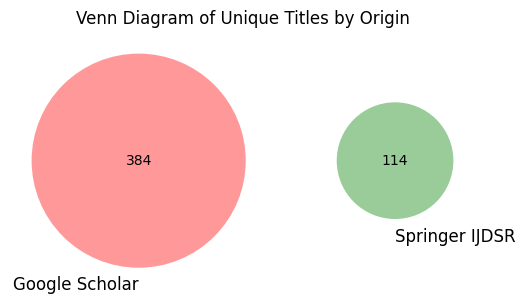

In [21]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Drop missing titles just in case
df = df_data.dropna(subset=['title'])

# Create sets of unique titles by origin
google_titles = set(
    df.loc[df['origin'] == 'Google Scholar', 'title']
)

springer_titles = set(
    df.loc[df['origin'] == 'Springer IJDSR', 'title']
)

# Compute regions
only_google = len(google_titles - springer_titles)
only_springer = len(springer_titles - google_titles)
intersection = len(google_titles & springer_titles)

# Plot
plt.figure(figsize=(6,6))
venn2(
    subsets=(only_google, only_springer, intersection),
    set_labels=('Google Scholar', 'Springer IJDSR')
)

plt.title('Venn Diagram of Unique Titles by Origin')
plt.show()


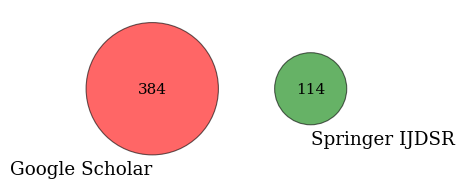

In [22]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import matplotlib as mpl

# --- Style configuration (Springer-like) ---
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11
})


google_titles = set(df.loc[df['origin'] == 'Google Scholar', 'title'])
springer_titles = set(df.loc[df['origin'] == 'Springer IJDSR', 'title'])

only_google = len(google_titles - springer_titles)
only_springer = len(springer_titles - google_titles)
intersection = len(google_titles & springer_titles)

# --- Plot ---
fig, ax = plt.subplots(figsize=(4.5, 4.5))

v = venn2(
    subsets=(only_google, only_springer, intersection),
    set_labels=('Google Scholar', 'Springer IJDSR'),
    ax=ax
)

# Subtle grayscale styling (journal-friendly)
for patch in v.patches:
    if patch:
        patch.set_alpha(0.6)
        patch.set_edgecolor('black')
        patch.set_linewidth(0.8)

# Remove background clutter
ax.set_axis_off()

plt.tight_layout()
plt.show()